# What a vision model sees

Companion notebook to [*post title*](https://axiom-ai.tech/generative-ai/vision/02-bird-ball-car/) on axiom-ai.tech.

This notebook takes a photograph, cuts it into squares the way a Vision Transformer does, and asks the model what it sees. The model is ViT-B/16 (Dosovitskiy et al., 2021), trained on ImageNet, so it can only answer with one of 1,000 labels. We try it on two photographs, a beetle and a squirrel, and then look at the list itself.

It runs on a GPU or a CPU. The first run downloads the model's weights, about 330 MB.

### 1. Setup

Imports, the folder holding the photographs, and the device. The first two lines are for Windows: torch and the plotting libraries can each bring their own copy of the OpenMP runtime, and this lets the two coexist.

In [1]:
# Cell 1: setup. Paths, device, versions.
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # Windows: lets two OpenMP runtimes coexist

from pathlib import Path
import torch, torchvision
import matplotlib.pyplot as plt
from PIL import Image

POST_DIR = Path.cwd()                          # the folder this notebook sits in
IMAGE_PATH = POST_DIR / "photo-01.jpg"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("folder      :", POST_DIR.name)
print("image found :", IMAGE_PATH.exists())
print("torch       :", torch.__version__, "| torchvision:", torchvision.__version__)
print("device      :", DEVICE, torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")

folder      : 02-vision-transformer
image found : True
torch       : 2.11.0+cu128 | torchvision: 0.26.0+cu128
device      : cuda NVIDIA GeForce RTX 3060


### 2. What the model sees

The model never sees the whole photograph. It resizes it, keeps a 224 × 224 square from the centre, and cuts that square into a 14 × 14 grid of 16-pixel patches: 196 in all. The figure shows the photograph beside the grid.

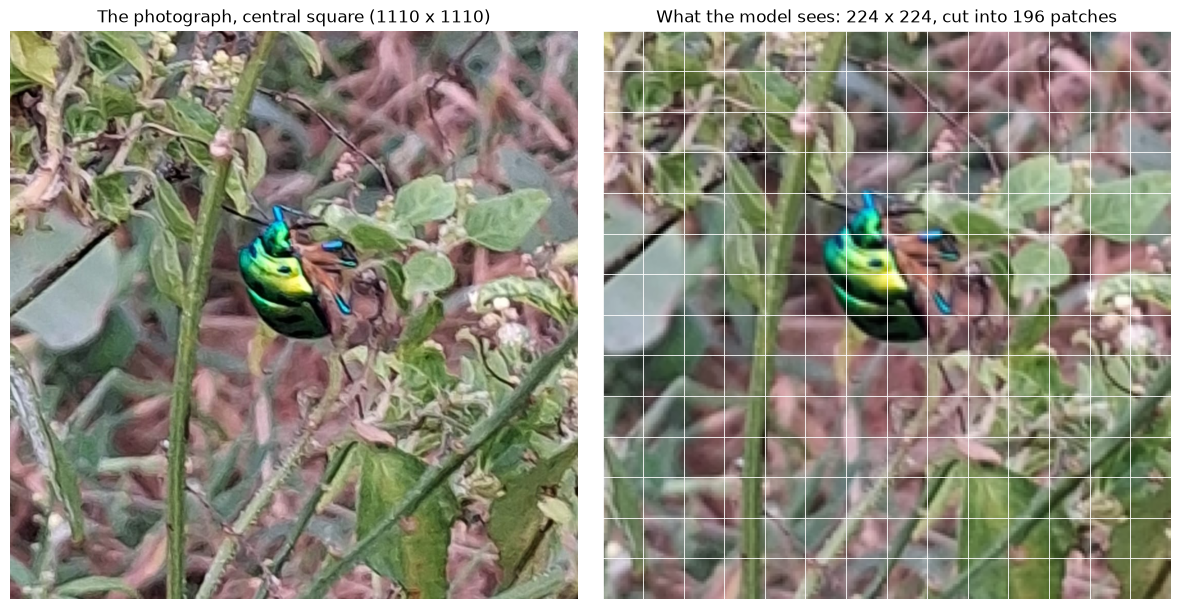

In [2]:
# Cell 2: what the model sees. The photograph, cut to its central square,
# then resized, cropped to 224 pixels, and cut into a 14x14 grid.
from PIL import ImageOps
from torchvision.transforms import functional as F

def load_square(path):
    """Open a photograph, respect its orientation, and keep the central square."""
    im = ImageOps.exif_transpose(Image.open(path)).convert("RGB")
    return F.center_crop(im, min(im.size))

def grid_figure(im, filename):
    crop = F.center_crop(F.resize(im, 256), 224)   # the same resize and crop the model uses
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(im)
    axes[0].set_title(f"The photograph, central square ({im.width} x {im.height})")
    axes[1].imshow(crop)
    axes[1].set_title("What the model sees: 224 x 224, cut into 196 patches")
    for k in range(0, 225, 16):
        axes[1].axhline(k - 0.5, color="white", lw=0.6)
        axes[1].axvline(k - 0.5, color="white", lw=0.6)
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    fig.savefig(POST_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

img = load_square(IMAGE_PATH)
grid_figure(img, "figure-01-grid.png")

### 3. From squares to tokens

The cutting is a single convolution: a 16 × 16 filter that moves 16 pixels at a time, so each step lands on exactly one square. Each square becomes a list of 768 numbers, a token. A class token is added at the front, where the answer will gather, and every token has a learned position. The last check confirms that these steps match the library's own.

In [3]:
# Cell 3: cutting the picture. One convolution turns 196 squares into 196 tokens.
from torchvision.models import vit_b_16, ViT_B_16_Weights

weights = ViT_B_16_Weights.IMAGENET1K_V1
model = vit_b_16(weights=weights).eval().to(DEVICE)

x = weights.transforms()(img).unsqueeze(0).to(DEVICE)   # resize 256, crop 224, normalise

with torch.no_grad():
    patches = model.conv_proj(x)                          # the patch cutter
    tokens = patches.flatten(2).transpose(1, 2)           # 14 x 14 grid -> a row of 196
    cls = model.class_token.expand(1, -1, -1)             # the extra token that will carry the answer
    sequence = torch.cat([cls, tokens], dim=1)
    same = torch.allclose(tokens, model._process_input(x))  # is this what the library does itself?

print("the cutter      :", model.conv_proj)
print("picture         :", tuple(x.shape), "  3 colours x 224 x 224 pixels")
print("after cutting   :", tuple(patches.shape), "  768 numbers for each of 14 x 14 squares")
print("as a sequence   :", tuple(tokens.shape), "  196 tokens, like 196 words")
print("with class token:", tuple(sequence.shape))
print("positions       :", tuple(model.encoder.pos_embedding.shape), "  one learned position per token")
print("same as library :", same)
print("numbers in one square:", 16 * 16 * 3)

the cutter      : Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
picture         : (1, 3, 224, 224)   3 colours x 224 x 224 pixels
after cutting   : (1, 768, 14, 14)   768 numbers for each of 14 x 14 squares
as a sequence   : (1, 196, 768)   196 tokens, like 196 words
with class token: (1, 197, 768)
positions       : (1, 197, 768)   one learned position per token
same as library : True
numbers in one square: 768


 75.3%  leaf beetle
  6.9%  tiger beetle
  2.7%  fly
  2.5%  ground beetle
  0.5%  bee


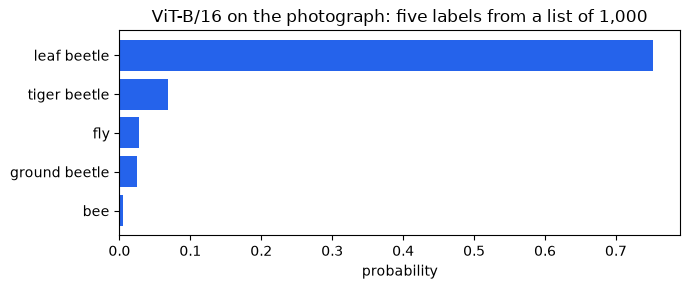

In [4]:
# Cell 4: the answer. One word from a list of a thousand.
with torch.no_grad():
    probs = model(x).softmax(dim=-1)[0]
top = probs.topk(5)
labels = weights.meta["categories"]

for p, i in zip(top.values.tolist(), top.indices.tolist()):
    print(f"{p:6.1%}  {labels[i]}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh([labels[i] for i in top.indices.tolist()][::-1], top.values.tolist()[::-1], color="#2563EB")
ax.set_xlabel("probability")
ax.set_title("ViT-B/16 on the photograph: five labels from a list of 1,000")
plt.tight_layout()
fig.savefig(POST_DIR / "figure-02-top5.png", dpi=150, bbox_inches="tight")
plt.show()

  9.8%  marmoset
  5.6%  mongoose
  4.5%  boa constrictor
  4.4%  macaque
  4.0%  capuchin


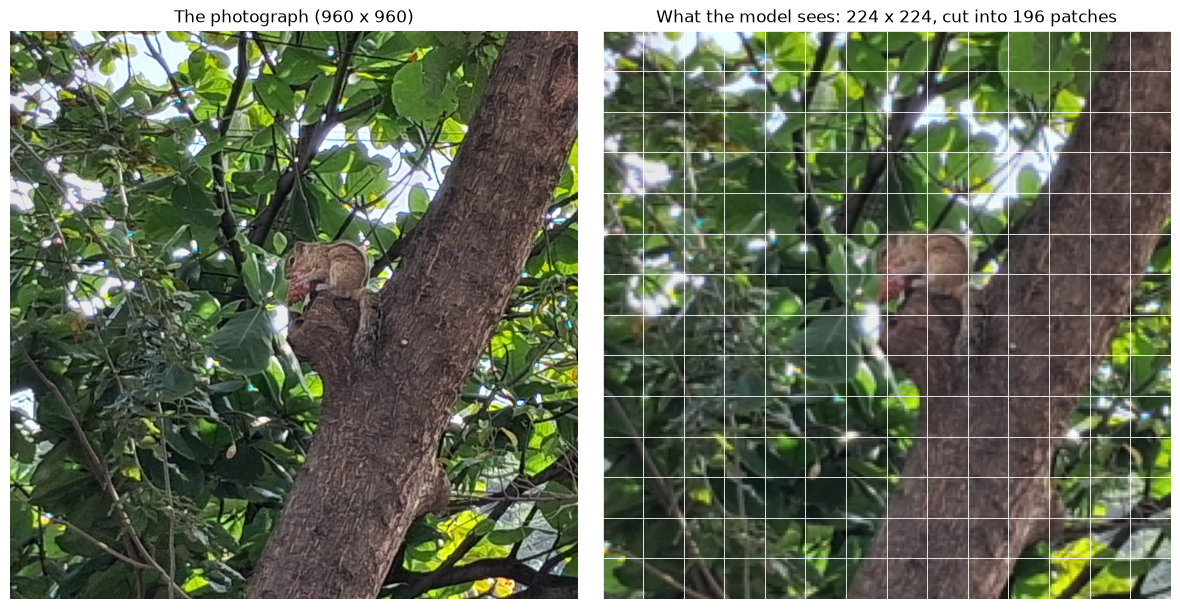

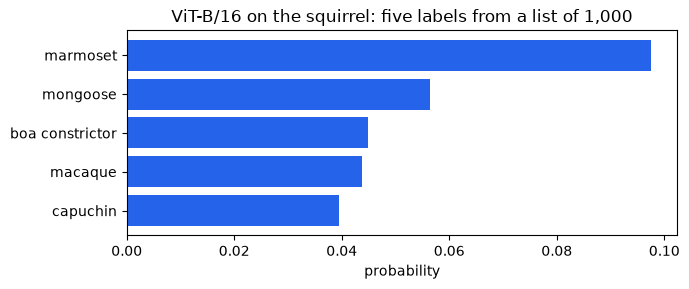

In [7]:
# Cell 5: the same eye, a second photograph. The busy squirrel.
def look(im, top_k=5):
    with torch.no_grad():
        p = model(weights.transforms()(im).unsqueeze(0).to(DEVICE)).softmax(dim=-1)[0]
    t = p.topk(top_k)
    return [(labels[i], v) for v, i in zip(t.values.tolist(), t.indices.tolist())]

im2 = load_square(POST_DIR / "photo-02.jpg")
answers = look(im2)
for name, p in answers:
    print(f"{p:6.1%}  {name}")

grid_figure(im2, "figure-03-squirrel-grid.png")

names, values = zip(*answers)
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(list(names)[::-1], list(values)[::-1], color="#2563EB")
ax.set_xlabel("probability")
ax.set_title("ViT-B/16 on the squirrel: five labels from a list of 1,000")
plt.tight_layout()
fig.savefig(POST_DIR / "figure-04-squirrel-top5.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Cell 6: the list itself. What words does the model have?
beetles   = [l for l in labels if "beetle" in l]   # misses a few, e.g. ladybug and weevil
squirrels = [l for l in labels if "squirrel" in l]
print(len(labels), "labels in all")
print(len(beetles), "beetles  :", beetles)
print(len(squirrels), "squirrels:", squirrels)

1000 labels in all
6 beetles  : ['tiger beetle', 'ground beetle', 'long-horned beetle', 'leaf beetle', 'dung beetle', 'rhinoceros beetle']
2 squirrels: ['fox squirrel', 'squirrel monkey']


Copyright 2026 Anirban Datta
SPDX-License-Identifier: Apache-2.0